In [1]:
from fastai.vision.all import *

In [2]:
def label_func(f):
  name = f.name
  return name[0].isupper()

splitter = RandomSplitter(valid_pct=0.2)

pets = DataBlock(blocks=(ImageBlock, CategoryBlock),  # définition du TYPE d'entrée / sortie
                 get_items=get_image_files,           # définition du CHARGEMENT des entrées
                 get_y = label_func,                  # définition du CHARGEMENT des sorties
                 splitter=splitter)                   # définition de la SEPARATION des données (train, validation)

In [3]:
pets = DataBlock(blocks=(ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 get_y = label_func,
                 splitter=splitter,
                 item_tfms=Resize((200,200)))          # Changer la résolution les images pour obtenir une taille de 100x100 pour toutes

torch.Size([8, 3, 200, 200])


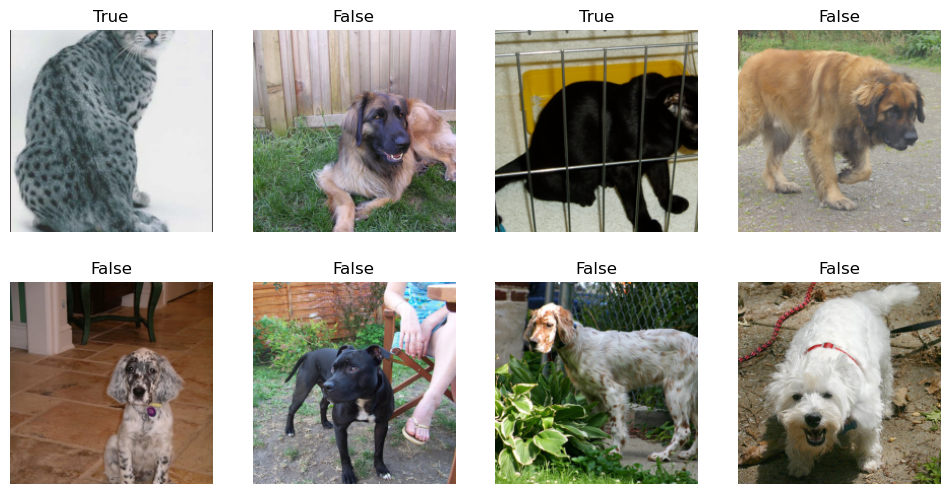

In [4]:
dls = pets.dataloaders(untar_data(URLs.PETS)/"images", bs=8) #Ici, entrée = liste de paths
dls.show_batch()
print(dls.one_batch()[0].shape)

torch.Size([8, 3, 200, 200])


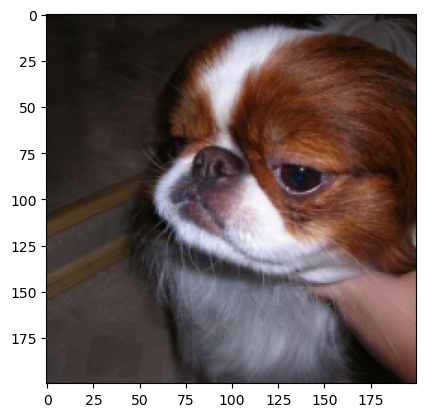

In [5]:
import matplotlib.pyplot as plt
batch1 = dls.one_batch()[0]
print(batch1.shape)
b = batch1[0]
plt.imshow(b.cpu().permute(1,2,0))


In [ ]:
from scores_utils import compute_fft_scores

### Define the Dataloader
data_path = untar_data(URLs.PETS) #checker les autres databases dispo
print(data_path.ls())

catblock = MultiCategoryBlock(encoded=True, vocab=['cat', 'dog'])
dblock = DataBlock(
    blocks=(ImageBlock(), catblock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=label_func,
    item_tfms=Resize(128),
    batch_tfms=[Normalize.from_stats(*imagenet_stats)],
)

# Créez un DataLoader
dls = dblock.dataloaders(data_path/"images", bs=16, drop_last=True)


liste_fichiers = dls.train.items + dls.valid.items


/opt/anaconda3/envs/general/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[Path('/Users/arda/.fastai/data/oxford-iiit-pet/images'), Path('/Users/arda/.fastai/data/oxford-iiit-pet/annotations')]


Calcul des scores FFT: 100%|██████████| 7390/7390 [00:15<00:00, 484.76it/s]

7390


In [ ]:
# -----------test du score de RATIO D'ENERGIE HAUTES FREQUENCES----------------
scores = compute_fft_scores(liste_fichiers)

#nombre d'images dont on a calculé le score
print(len(scores))

# Affichage des scores
print(scores)

Calcul des scores FFT: 100%|██████████| 7390/7390 [00:15<00:00, 470.36it/s]

7390
[0.5244304537773132, 0.4455052316188812, 0.5916998386383057, 0.5086277723312378, 0.4752843379974365, 0.5196758508682251, 0.42316263914108276, 0.5568410158157349, 0.5224586725234985, 0.4283488392829895, 0.4319830536842346, 0.39574921131134033, 0.39617854356765747, 0.5158515572547913, 0.48918312788009644, 0.47092464566230774, 0.4810897409915924, 0.5374572277069092, 0.33311885595321655, 0.4045912027359009, 0.3729307949542999, 0.4788285195827484, 0.5594390034675598, 0.5698171854019165, 0.4156118333339691, 0.5051188468933105, 0.4932304322719574, 0.42745083570480347, 0.5882968902587891, 0.514359712600708, 0.38787680864334106, 0.5028653144836426, 0.5656377673149109, 0.44341111183166504, 0.43993955850601196, 0.5366761088371277, 0.45586204528808594, 0.4055418074131012, 0.5792471170425415, 0.5955466032028198, 0.5050367712974548, 0.38692209124565125, 0.46400007605552673, 0.5799866914749146, 0.4632816016674042, 0.48625463247299194, 0.44075775146484375, 0.5321744084358215, 0.43272289633750916,

In [ ]:
# -----------test du score de ??????----------------
